# Phase 5 — Fine-tuning LLaMA 3.2 1B
## Educational Rewriter GPT

Fine-tuning LLaMA 3.2 1B with QLoRA on 846 educational rewrite pairs across 6 modes.

**Model:** meta-llama/Llama-3.2-1B  
**Method:** QLoRA (4-bit quantisation, LoRA rank 16)  
**Dataset:** 846 examples (612 train / 138 val / 96 test)  
**Modes:** Default, Simpler, Add Example, Concise, Step by Step, Add Analogy  
**Platform:** Kaggle (Tesla T4 GPU, 15.6 GB)

---

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"  # Must be FIRST before any imports

import torch
print(f"GPUs visible: {torch.cuda.device_count()}")
print(f"GPU name: {torch.cuda.get_device_name(0)}")

GPUs visible: 1
GPU name: Tesla T4


### Checking the dataset


In [2]:
# Clone your GitHub repo to get the dataset
!git clone https://github.com/aniray2908/nlp-llm-journey.git

# Verify dataset is there
import os
dataset_path = "nlp-llm-journey/05_rewriter_gpt/data/processed/dataset"
print(f"Dataset exists: {os.path.exists(dataset_path)}")

splits = ["train", "validation", "test"]
for split in splits:
    split_path = f"{dataset_path}/{split}"
    if os.path.exists(split_path):
        files = os.listdir(split_path)
        print(f"  {split}: {files}")

Cloning into 'nlp-llm-journey'...
remote: Enumerating objects: 419, done.
remote: Counting objects: 100% (198/198), done.
remote: Compressing objects: 100% (163/163), done.
remote: Total 419 (delta 63), reused 0 (delta 0), pack-reused 221 (from 1)
Receiving objects: 100% (419/419), 2.42 MiB | 10.64 MiB/s, done.
Resolving deltas: 100% (127/127), done.
Dataset exists: True
  train: ['data-00000-of-00001.arrow', 'dataset_info.json', 'state.json']
  validation: ['data-00000-of-00001.arrow', 'dataset_info.json', 'state.json']
  test: ['data-00000-of-00001.arrow', 'dataset_info.json', 'state.json']



### Installing libraries

In [3]:
!pip install -q transformers peft accelerate bitsandbytes trl datasets sentencepiece

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 32.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 721.6/721.6 kB 41.1 MB/s eta 0:00:00



### HuggingFace authentication


In [16]:
from huggingface_hub import login
from kaggle_secrets import UserSecretsClient

# Get HuggingFace token from Kaggle Secrets (safe — not hardcoded)
secrets = UserSecretsClient()
hf_token = secrets.get_secret("HF_TOKEN")

login(token=hf_token)
print("✅ HuggingFace login successful!")

from kaggle_secrets import UserSecretsClient
secrets = UserSecretsClient()
hf_write_token = secrets.get_secret("HF_WRITE_TOKEN")

from huggingface_hub import login
login(token=hf_write_token)
print(f"Logged in as: {whoami()['name']}")

✅ HuggingFace login successful!
Logged in as: ray-2908



### Loading dataset


In [5]:
from datasets import load_from_disk

dataset_path = "nlp-llm-journey/05_rewriter_gpt/data/processed/dataset"
dataset = load_from_disk(dataset_path)

print(f"Dataset loaded!")
print(f"\nSplits:")
print(f"  Train:      {len(dataset['train'])} examples")
print(f"  Validation: {len(dataset['validation'])} examples")
print(f"  Test:       {len(dataset['test'])} examples")

print(f"\nFeatures: {dataset['train'].features}")

print(f"\nSample training example:")
sample = dataset['train'][0]
print(f"  Mode:   {sample['mode']}")
print(f"  Source: {sample['source']}")
print(f"  Text preview:\n{sample['text'][:300]}...")

Dataset loaded!

Splits:
  Train:      612 examples
  Validation: 138 examples
  Test:       96 examples

Features: {'text': Value('string'), 'input': Value('string'), 'mode': Value('string'), 'output': Value('string'), 'prompt_style': Value('string'), 'source': Value('string'), 'topic': Value('string')}

Sample training example:
  Mode:   default
  Source: wikipedia
  Text preview:
<|system|>
You are an expert educational content rewriter.
Rewrite text clearly based on the requested mode.
Preserve the original meaning exactly.
Output ONLY the rewrite, nothing else.
<|user|>
Mode: Default
Text: '''Natural language processing''' ('''NLP''') is the processing of natural language ...



### Loading LLaMA 3.2 1B with QLoRA


In [6]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

model_name = "meta-llama/Llama-3.2-3B"

# 4-bit quantisation config (QLoRA)
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

print("Loading model in 4-bit...")
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
)

print("Preparing model for QLoRA training...")
model = prepare_model_for_kbit_training(model)

# LoRA config
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "v_proj", "k_proj", "o_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
)

model = get_peft_model(model, lora_config)

# Print parameter counts
total = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\nModel loaded")
print(f"Total parameters:     {total:,}")
print(f"Trainable parameters: {trainable:,} ({trainable/total*100:.2f}%)")
print(f"Frozen parameters:    {total-trainable:,} ({(total-trainable)/total*100:.2f}%)")

Loading tokenizer...


config.json:   0%|          | 0.00/844 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/301 [00:00<?, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/185 [00:00<?, ?B/s]

Preparing model for QLoRA training...

Model loaded
Total parameters:     1,812,638,720
Trainable parameters: 9,175,040 (0.51%)
Frozen parameters:    1,803,463,680 (99.49%)



### Training setup


In [7]:
from trl import SFTTrainer, SFTConfig

training_args = SFTConfig(
    output_dir="./checkpoints",
    num_train_epochs=3,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=8,
    learning_rate=2e-4,
    lr_scheduler_type="cosine",
    warmup_steps=50,
    weight_decay=0.01,
    max_grad_norm=1.0,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    logging_steps=10,
    fp16=False,       # ← changed to False
    bf16=True,        # ← added bf16
    max_length=512,
    dataset_text_field="text",
    report_to="none",
)

trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=dataset["train"],
    eval_dataset=dataset["validation"],
    processing_class=tokenizer,   # ← changed from tokenizer
)

print("Trainer configured!")
print(f"\nTraining config:")
print(f"  Epochs:                {training_args.num_train_epochs}")
print(f"  Batch size:            {training_args.per_device_train_batch_size}")
print(f"  Gradient accumulation: {training_args.gradient_accumulation_steps}")
print(f"  Effective batch size:  {training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps}")
print(f"  Learning rate:         {training_args.learning_rate}")
print(f"  Max length:            {training_args.max_length}")

Adding EOS to train dataset:   0%|          | 0/612 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/612 [00:00<?, ? examples/s]

Adding EOS to eval dataset:   0%|          | 0/138 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/138 [00:00<?, ? examples/s]

Trainer configured!

Training config:
  Epochs:                3
  Batch size:            2
  Gradient accumulation: 8
  Effective batch size:  16
  Learning rate:         0.0002
  Max length:            512



### Training


In [8]:
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "0"

print(f"Using single GPU: {torch.cuda.get_device_name(0)}")
print(f"GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Using single GPU: Tesla T4
GPU memory: 15.6 GB


In [9]:
import time

print("Starting fine-tuning...")
print("="*60)

start_time = time.time()

# Train!
train_result = trainer.train()

end_time = time.time()
elapsed = (end_time - start_time) / 60

print("\n" + "="*60)
print("TRAINING COMPLETE!")
print("="*60)
print(f"\nTotal training time: {elapsed:.1f} minutes")
print(f"Training loss:       {train_result.training_loss:.4f}")
print(f"\nTraining metrics:")
for key, val in train_result.metrics.items():
    print(f"  {key}: {val:.4f}" if isinstance(val, float) else f"  {key}: {val}")

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 128001}.


Starting fine-tuning...


Epoch,Training Loss,Validation Loss
1,1.737374,1.182671
2,1.149292,1.085791
3,1.044470,1.064598



TRAINING COMPLETE!

Total training time: 150.3 minutes
Training loss:       1.3859

Training metrics:
  train_runtime: 9019.8134
  train_samples_per_second: 0.2040
  train_steps_per_second: 0.0130
  total_flos: 14253373823594496.0000
  train_loss: 1.3859



### Saving LoRA adapters


In [10]:
# Save LoRA adapters
adapter_save_path = "./lora_adapters"
model.save_pretrained(adapter_save_path)
tokenizer.save_pretrained(adapter_save_path)

print(f"LoRA adapters saved to {adapter_save_path}")

# Check what was saved
import os
files = os.listdir(adapter_save_path)
print(f"\nSaved files:")
for f in files:
    size = os.path.getsize(f"{adapter_save_path}/{f}") / (1024*1024)
    print(f"  {f}: {size:.1f} MB")

LoRA adapters saved to ./lora_adapters

Saved files:
  tokenizer_config.json: 0.0 MB
  adapter_model.safetensors: 35.0 MB
  adapter_config.json: 0.0 MB
  README.md: 0.0 MB
  tokenizer.json: 16.4 MB



### Training curves


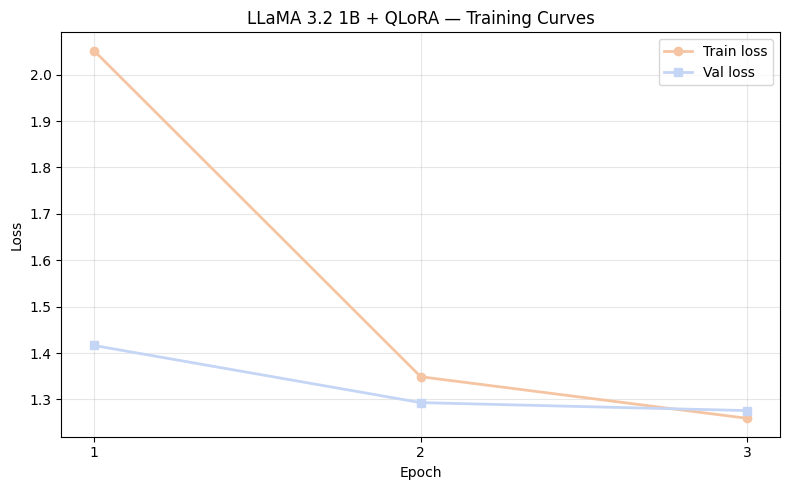

Key observations:
  Train loss: 2.052 → 1.259 (↓ 0.793)
  Val loss:   1.416 → 1.276 (↓ 0.140)
  Gap (epoch 3): 0.017 ← small gap = no overfitting


In [11]:
import matplotlib.pyplot as plt

epochs = [1, 2, 3]
train_losses = [2.051714, 1.348866, 1.259148]
val_losses = [1.416237, 1.293058, 1.275845]

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_losses, marker='o', label='Train loss', 
         color='#f5c5a3', linewidth=2)
plt.plot(epochs, val_losses, marker='s', label='Val loss', 
         color='#c5d5f5', linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("LLaMA 3.2 1B + QLoRA — Training Curves")
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(epochs)
plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()

print("Key observations:")
print(f"  Train loss: {train_losses[0]:.3f} → {train_losses[-1]:.3f} (↓ {train_losses[0]-train_losses[-1]:.3f})")
print(f"  Val loss:   {val_losses[0]:.3f} → {val_losses[-1]:.3f} (↓ {val_losses[0]-val_losses[-1]:.3f})")
print(f"  Gap (epoch 3): {abs(train_losses[-1] - val_losses[-1]):.3f} ← small gap = no overfitting")


### Qualitative evaluation


In [14]:
from peft import PeftModel
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
import torch

def generate_rewrite(model, tokenizer, text, mode, max_new_tokens=256):
    """Generate a rewrite using the fine-tuned model."""
    
    # Mode-specific system prompts
    mode_instructions = {
        "Default": """You are an expert educational content rewriter.
Rewrite the text to be clearer and easier to understand.
Improve readability while preserving the original meaning exactly.
Output ONLY the rewrite, nothing else.""",

        "Simpler": """You are an expert educational content rewriter.
Rewrite the text so a 16-year-old with no technical background can understand it.
Replace ALL technical terms with everyday words.
Use short sentences. Maximum 15 words per sentence.
Never use acronyms or jargon.
If a technical term is unavoidable, explain it in brackets.
Output ONLY the rewrite, nothing else.""",

        "Add Example": """You are an expert educational content rewriter.
Rewrite the text and add ONE concrete example that directly illustrates the concept.
The example MUST be about the exact same topic as the input text.
Do not use unrelated examples from different domains.
Format: original explanation + "For example, ..." 
Output ONLY the rewrite with example, nothing else.""",

        "Concise": """You are an expert educational content rewriter.
Rewrite the text using fewer words while keeping the same meaning.
Remove redundancy and filler phrases.
Do not remove important information.
Output ONLY the shorter rewrite, nothing else.""",

        "Step by Step": """You are an expert educational content rewriter.
Break down HOW THIS CONCEPT WORKS into clear numbered steps.
Each step must explain part of the mechanism described in the original text.
Do NOT explain history. Do NOT add information not in the original text.
Format strictly as:
1. [first part of the mechanism]
2. [second part]
3. [third part]
Output ONLY the numbered steps, nothing else.""",

        "Add Analogy": """You are an expert educational content rewriter.
Rewrite the text and add a real-world analogy that makes the concept concrete.
The analogy must map clearly to the concept in the original text.
Explain why the analogy applies.
Output ONLY the rewrite with analogy, nothing else.""",
    }
    
    system = mode_instructions.get(mode, mode_instructions["Default"])
    prompt = f"<|system|>\n{system}\n<|user|>\nText: {text}\n<|assistant|>\n"
    
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=0.7,
            top_p=0.95,
            top_k=50,
            do_sample=True,
            repetition_penalty=1.3,
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )
    
    new_tokens = outputs[0][inputs['input_ids'].shape[1]:]
    return tokenizer.decode(new_tokens, skip_special_tokens=True).strip()
    
# Test passage
test_passage = """
The transformer architecture fundamentally differs from 
recurrent neural networks in its approach to sequence modeling. 
Rather than processing tokens sequentially through hidden states 
that must encode all previous context, transformers employ 
self-attention mechanisms that allow each position in the sequence 
to directly attend to all other positions simultaneously, computing 
relevance scores through scaled dot-product operations between 
query, key, and value projections of the input embeddings, 
thereby enabling parallel computation and eliminating the 
sequential bottleneck that limits the scalability of recurrent 
approaches to long-range dependency modeling.
"""
print("="*60)
print("QUALITATIVE EVALUATION — ALL 6 MODES")
print("="*60)
print(f"\nOriginal ({len(test_passage.split())} words):")
print(test_passage)

modes = {
    "Default": "Default",
    "Simpler": "Simpler", 
    "Add Example": "Add Example",
    "Concise": "Concise",
    "Step by Step": "Step by Step",
    "Add Analogy": "Add Analogy",
}

for mode_label, mode_prompt in modes.items():
    print(f"\n{'─'*60}")
    print(f"Mode: {mode_label.upper()}")
    rewrite = generate_rewrite(model, tokenizer, test_passage, mode_prompt)
    print(f"Output ({len(rewrite.split())} words):")
    print(rewrite)

print(f"\n{'='*60}")
print("Qualitative check complete!")

QUALITATIVE EVALUATION — ALL 6 MODES

Original (85 words):

The transformer architecture fundamentally differs from 
recurrent neural networks in its approach to sequence modeling. 
Rather than processing tokens sequentially through hidden states 
that must encode all previous context, transformers employ 
self-attention mechanisms that allow each position in the sequence 
to directly attend to all other positions simultaneously, computing 
relevance scores through scaled dot-product operations between 
query, key, and value projections of the input embeddings, 
thereby enabling parallel computation and eliminating the 
sequential bottleneck that limits the scalability of recurrent 
approaches to long-range dependency modeling.


────────────────────────────────────────────────────────────
Mode: DEFAULT
Output (131 words):
**Transformer Architecture vs Recurrent Neural Networks**
While both architectures process sequences as inputs, they work differently:

* **Recurrent:** These models


### Pushing to HuggingFace Hub


In [18]:
from huggingface_hub import HfApi
import json
import os

# Login check
from huggingface_hub import whoami
print(f"Logged in as: {whoami()['name']}")

# Push LoRA adapters to HuggingFace Hub
repo_id = "ray-2908/educational-rewriter-lora"

print(f"\nPushing to: {repo_id}")

model.push_to_hub(
    repo_id,
    commit_message="Add Phase 5 Educational Rewriter LoRA adapters (LLaMA 3.2 3B, QLoRA rank 16)",
    private=True,  # Start private, make public after model card
)

tokenizer.push_to_hub(
    repo_id,
    commit_message="Add tokenizer",
    private=True,
)

print(f"\nSuccessfully pushed to HuggingFace Hub!")
print(f"Model URL: https://huggingface.co/{repo_id}")
print(f"\nNext: Write model card, then make public")

Logged in as: ray-2908

Pushing to: ray-2908/educational-rewriter-lora


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

No files have been modified since last commit. Skipping to prevent empty commit.


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

No files have been modified since last commit. Skipping to prevent empty commit.



Successfully pushed to HuggingFace Hub!
Model URL: https://huggingface.co/ray-2908/educational-rewriter-lora

Next: Write model card, then make public
